## Importing Necessary Libraries

In [ ]:
#Importing Necccerary Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Loading dataset

In [ ]:
# Load the dataset
df_raw = pd.read_csv(groceries.csv)

In [ ]:
df_data.head()

,Member_number,Date,Item_description
0,1249,01-01-2014,Citrus Fruit
1,1249,01-01-2014,Coffee
2,1381,01-01-2014,Curd
3,1381,01-01-2014,Soda
4,1440,01-01-2014,Other Vegetables


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38006 entries, 0 to 38005
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Member_number     38006 non-null  int64 
 1   Date              38006 non-null  object
 2   Item_description  38006 non-null  object
dtypes: int64(1), object(2)
memory usage: 890.9+ KB


## Data Cleaning

### **I. Handling Missing Values**

In [ ]:
df_data.isnull().sum().sort_values(ascending=False)

,0
Member_number,0
Date,0
Item_description,0


There is no null value

### **II. Remove Duplicate Values**

In [ ]:
#Check duplicated data
df_data.duplicated().sum()

np.int64(0)

In [ ]:
df_data= df_data.drop_duplicates()
#Check duplicated data
df_data.duplicated().sum()

np.int64(0)

### **III. Convert Data Types**

In [ ]:
# To get the dataset Info
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38006 entries, 0 to 38005
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Member_number     38006 non-null  int64 
 1   Date              38006 non-null  object
 2   Item_description  38006 non-null  object
dtypes: int64(1), object(2)
memory usage: 890.9+ KB


## Exploratory Data Analysis (EDA)

In [ ]:
# Convert the data type of dataframe
# Convert member_number from Int to String
df_data['Member_number'] = df_data['Member_number'].astype(str)

# Convert Date types to datetime
df_data['Date'] = pd.to_datetime(df_data['Date'], format='%d-%m-%Y', dayfirst=True)


df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38006 entries, 0 to 38005
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Member_number     38006 non-null  object        
 1   Date              38006 non-null  datetime64[ns]
 2   Item_description  38006 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 890.9+ KB


##### **1. What is the total of the product?**

In [ ]:
all_products = df_data['Item_description'].unique()
print("Total products: {}".format(len(all_products)))

Total products: 167


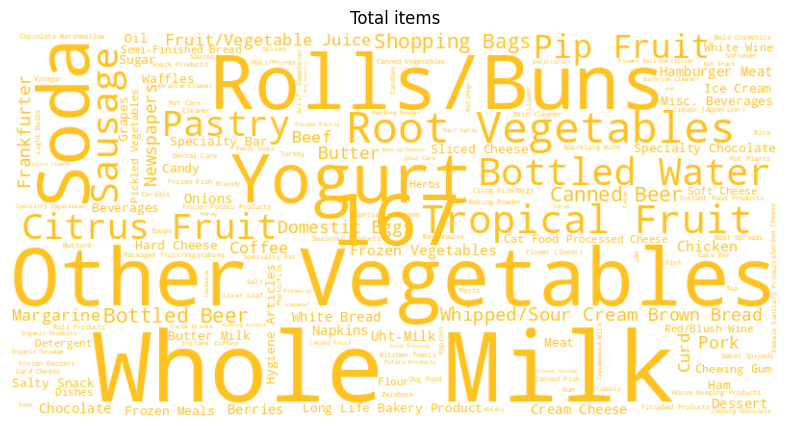

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all item descriptions into a single string
all_items_text = ' '.join(df_data['Item_description'])

# Define colors used in bar charts
base_color = '#ffc220'

# Create a dictionary of item frequencies
item_frequencies = df_data['Item_description'].value_counts().to_dict()

# Function to color words based on frequency
def color_func(word, **kwargs):
    return base_color


# Create the word cloud object with custom color function
wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate_from_frequencies(item_frequencies)


# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

# Define all_products for use in this cell
all_products = df_data['Item_description'].unique()

# Add the total number of unique products in the center with the specified color
plt.text(400, 200, str(len(all_products)), fontsize=50, color=base_color, ha='center', va='center')

plt.title('Total items')
plt.show()

#### **2. What is the top 5 customer ID which bought the most product**?

In [ ]:
df_data['Member_number'].value_counts().head()

,count
Member_number,
3180,35
3737,33
3050,32
2051,31
2433,30


#### **3. What is the TOP 5 items sold?**

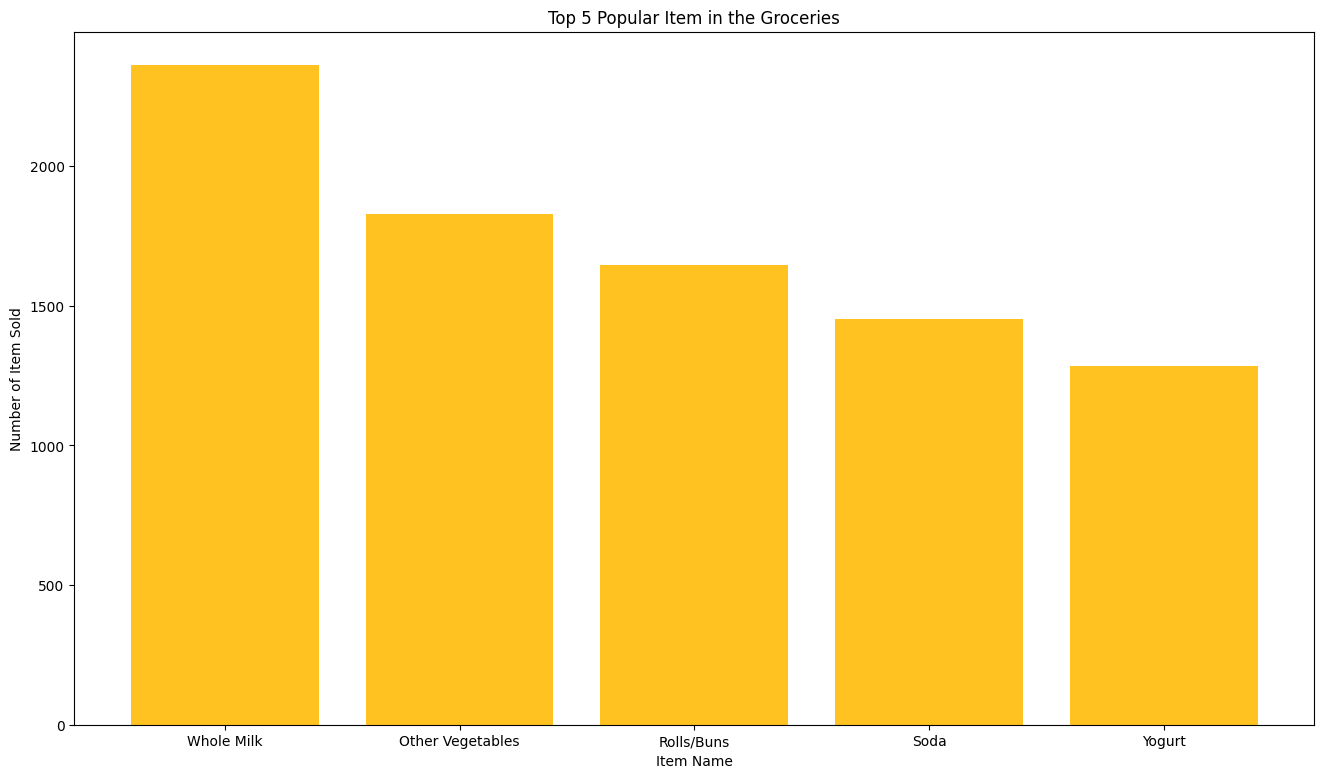

In [ ]:
## Creating distribution of Item Sold

Item_distr = df_data.groupby(by = "Item_description").size().reset_index(name='Frequency').sort_values(by = 'Frequency',ascending=False).head(5)

## Declaring variables

bars = Item_distr["Item_description"]
height = Item_distr["Frequency"]
x_pos = np.arange(len(bars))

# Define the color to be used
base_color = '#ffc220'

## Defining Figure Size

plt.figure(figsize=(16,9))

# Create bars with the single color
plt.bar(x_pos, height, color=base_color)

# Add title and axis names
plt.title("Top 5 Popular Item in the Groceries")
plt.xlabel("Item Name")
plt.ylabel("Number of Item Sold")

# Create names on the x-axis
plt.xticks(x_pos, bars)

# Show graph
plt.show()

#### **4. What is the TOP 5 least items sold?**

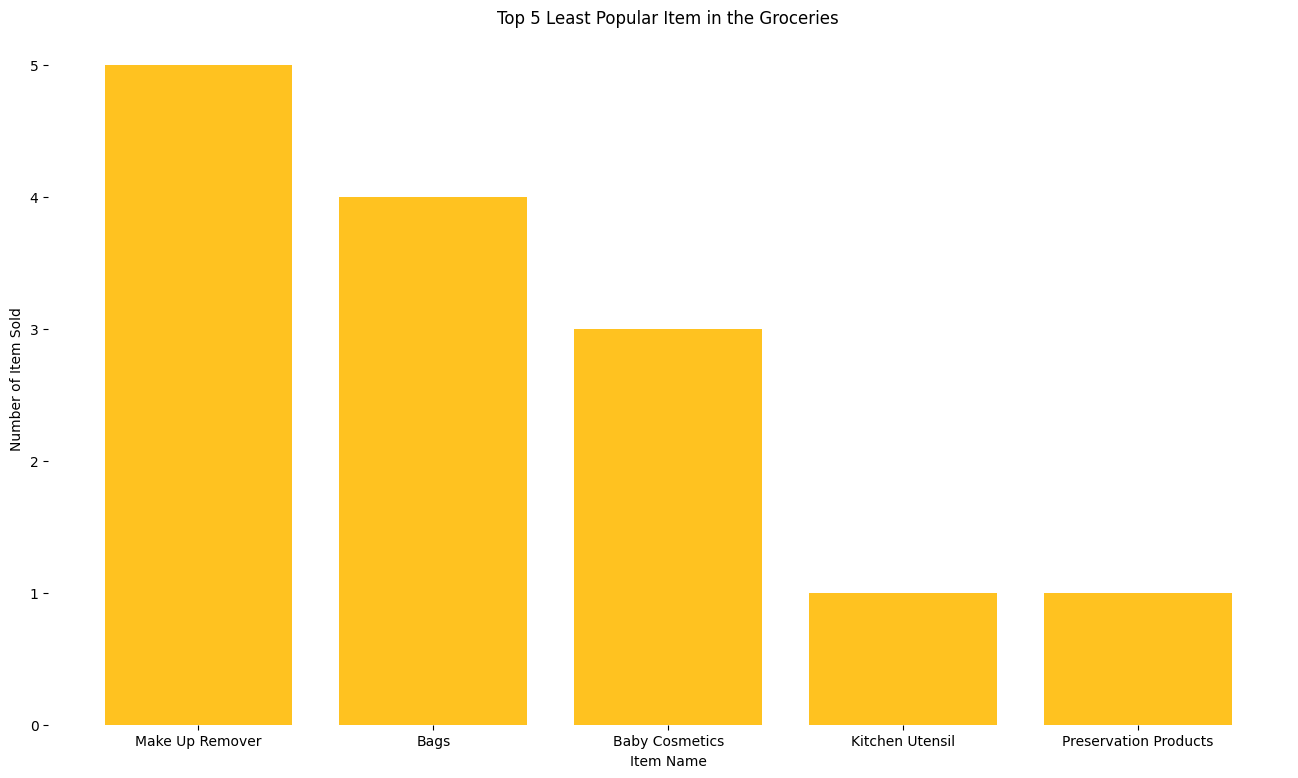

In [ ]:
## Creating distribution of Item Sold

Item_distr = df_data.groupby(by = "Item_description").size().reset_index(name='Frequency').sort_values(by = 'Frequency',ascending=False).tail(5)

## Declaring variables

bars = Item_distr["Item_description"]
height = Item_distr["Frequency"]
x_pos = np.arange(len(bars))

# Define the color to be used
base_color = '#ffc220'

## Defining Figure Size

plt.figure(figsize=(16,9))

# Create bars with the single color
plt.bar(x_pos, height, color=base_color)

# Add title and axis names
plt.title("Top 5 Least Popular Item in the Groceries")
plt.xlabel("Item Name")
plt.ylabel("Number of Item Sold")

# Create names on the x-axis
plt.xticks(x_pos, bars)

# Show graph
plt.show()

In [ ]:
product_counts = df_data['Item_description'].value_counts().reset_index()
product_counts.columns = ['Product', 'Count']
display(product_counts)

,Product,Count
0,Whole Milk,2363
1,Other Vegetables,1827
2,Rolls/Buns,1646
3,Soda,1453
4,Yogurt,1285
...,...,...
162,Toilet Cleaner,5
163,Bags,4
164,Baby Cosmetics,3
165,Preservation Products,1


#### **5. Order Sales Trend**

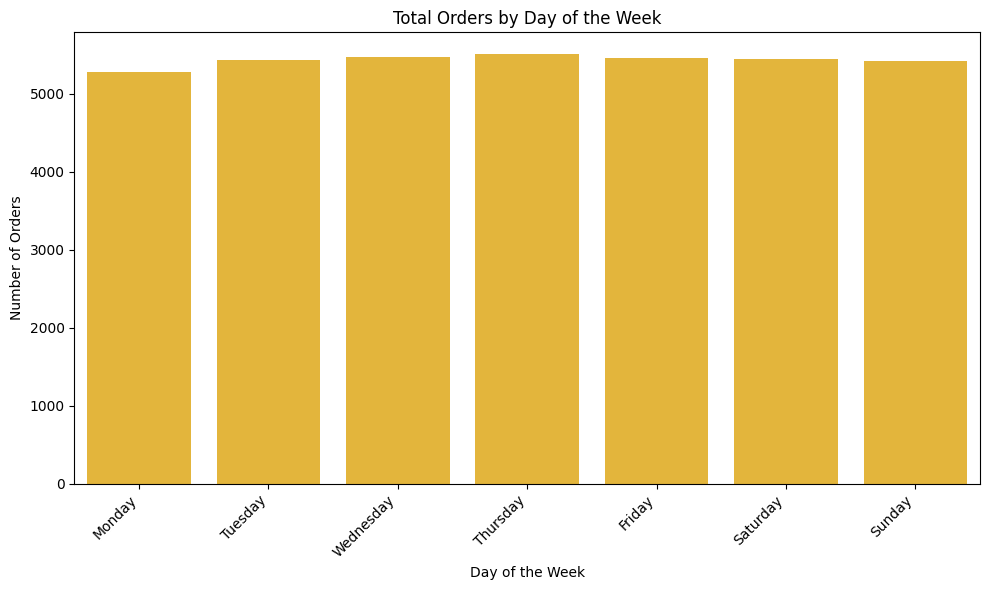

In [ ]:
# Convert 'Date' column to datetime if not already done
df_data['Date'] = pd.to_datetime(df_data['Date'], dayfirst=True)

# Extract the day of the week
df_data['Day_of_Week'] = df_data['Date'].dt.day_name()

# Count the number of orders by day of the week
orders_by_day = df_data['Day_of_Week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# Create a bar chart
plt.figure(figsize=(10, 6))

# Define the color to be used
base_color = '#ffc220'

# Create bars with the single color
ax = sns.barplot(x=orders_by_day.index, y=orders_by_day.values, color=base_color)

plt.title('Total Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# show graph
plt.show()

In [ ]:
# Count the number of orders by day of the week and create a DataFrame
orders_by_day_table = df_data['Day_of_Week'].value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()

# Rename the columns
orders_by_day_table.columns = ['Day of Week', 'Number of Orders']

# Display the table
display(orders_by_day_table)

,Day of Week,Number of Orders
0,Monday,5278
1,Tuesday,5433
2,Wednesday,5470
3,Thursday,5510
4,Friday,5451
5,Saturday,5444
6,Sunday,5420


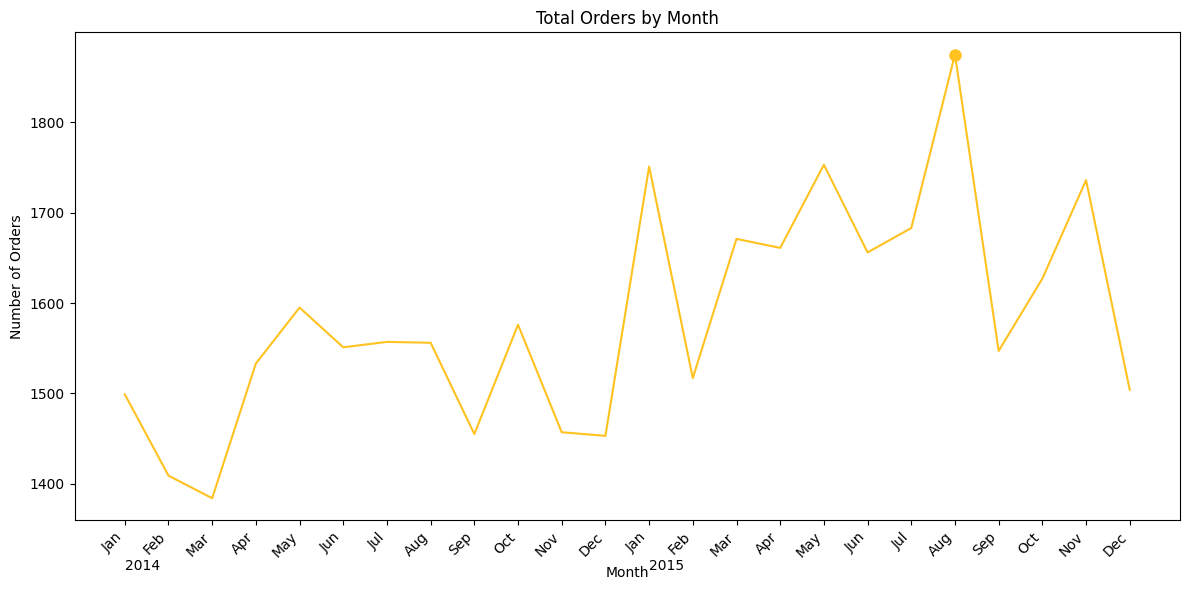

In [ ]:
# Extract the month and year
df_data['Month'] = df_data['Date'].dt.strftime('%B') # Extract month name
df_data['Month_Year'] = df_data['Date'].dt.to_period('M')


# Count the number of orders by month and year
orders_by_month = df_data.groupby('Month_Year')['Month'].count().sort_index()

# Format the index to 'Mon YYYY' string format for plotting
orders_by_month.index = orders_by_month.index.strftime('%b %Y')

# Create a line chart
plt.figure(figsize=(12, 6))

# Define the color to be used
base_color = '#ffc220'

# Find the peak month
peak_month_year = orders_by_month.idxmax()

# Plot the line with base color
plt.plot(orders_by_month.index, orders_by_month.values, color=base_color)

# Highlight the peak month with a marker using the same base_color
plt.plot(str(peak_month_year), orders_by_month[peak_month_year], marker='o', color=base_color, markersize=8)

# Set x-tick labels to month abbreviations
month_labels = [month.split(' ')[0] for month in orders_by_month.index]
plt.xticks(orders_by_month.index, month_labels, rotation=45, ha='right')

# Add year labels below the months
years = sorted(list(set([month.split(' ')[1] for month in orders_by_month.index])))
for year in years:
    # Find the index of the first month of the year
    first_month_index = [i for i, month_year in enumerate(orders_by_month.index) if year in month_year][0]
    plt.text(first_month_index, plt.ylim()[0] - (plt.ylim()[1] - plt.ylim()[0]) * 0.08, year, ha='left', va='top', color='black')


plt.title('Total Orders by Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')


plt.tight_layout()
plt.show()

In [ ]:
# Extract the month and year and count the number of orders
orders_by_month_table = df_data.groupby(df_data['Date'].dt.to_period('M')).size().reset_index(name='Number of Orders')

# Rename the columns
orders_by_month_table.columns = ['Month Year', 'Number of Orders']

# Convert 'Month Year' to string for better display if needed, or keep as period
orders_by_month_table['Month Year'] = orders_by_month_table['Month Year'].astype(str)

# Display the table
display(orders_by_month_table)

,Month Year,Number of Orders
0,2014-01,1499
1,2014-02,1409
2,2014-03,1384
3,2014-04,1533
4,2014-05,1595
5,2014-06,1551
6,2014-07,1557
7,2014-08,1556
8,2014-09,1455
9,2014-10,1576


## FP-Growth Implementation

**FP-Growth Algorithm**

We will now use the FP-growth algorithm, an alternative to Apriori, to find frequent itemsets and association rules. FP-growth can be more efficient than Apriori, especially with large datasets.

#### Data Preparation for FP-Growth

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Group by customer AND date to create proper baskets
basket_df = df_data.groupby(['Member_number', 'Date']).agg({
    'Item_description': lambda x: list(x),
    'Day_of_Week': 'first'
}).reset_index()

# Calculate basket size (moved here to ensure it's always available)
basket_df['basket_size'] = basket_df['Item_description'].apply(len)

# Prepare the transactions list for FP-growth
transactions = basket_df['Item_description'].tolist()

# Convert the list of transactions into a one-hot encoded DataFrame
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_fp = pd.DataFrame(te_ary, columns=te.columns_)

display(df_fp.head())

,Abrasive Cleaner,Artif. Sweetener,Baby Cosmetics,Bags,Baking Powder,Bathroom Cleaner,Beef,Berries,Beverages,Bottled Beer,...,Uht-Milk,Vinegar,Waffles,Whipped/Sour Cream,Whisky,White Bread,White Wine,Whole Milk,Yogurt,Zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


#### Run FP-Growth Algorithm

In [ ]:
# Find frequent itemsets using FP-growth
# We'll use a similar min_support as before (0.005)
frequent_itemsets = fpgrowth(df_fp, min_support=0.005, use_colnames=True)

print("\nFrequent Itemsets:")
display(frequent_itemsets.head())
print(f"\nTotal number of frequent itemsets: {len(frequent_itemsets)}")


Frequent Itemsets:


,support,itemsets
0,0.157923,(Whole Milk)
1,0.051728,(Pastry)
2,0.018780,(Salty Snack)
3,0.085879,(Yogurt)
4,0.060349,(Sausage)



Total number of frequent itemsets: 126


#### Generate Association Rules from Frequent Itemsets

In [ ]:
# Generate association rules
# We'll use a min_confidence of 0.05 to ensure rules are generated
rules_fp = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)

print("\nAssociation Rules (based on Confidence):")
display(rules_fp.head())


Association Rules (based on Confidence):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Pastry),(Whole Milk),0.051728,0.157923,0.006483,0.125323,0.793571,1.0,-0.001686,0.962729,-0.215266,0.031908,-0.038714,0.083186
1,(Whole Milk),(Yogurt),0.157923,0.085879,0.011161,0.070673,0.822940,1.0,-0.002401,0.983638,-0.203508,0.047975,-0.016634,0.100317
2,(Yogurt),(Whole Milk),0.085879,0.157923,0.011161,0.129961,0.822940,1.0,-0.002401,0.967861,-0.190525,0.047975,-0.033206,0.100317
3,(Yogurt),(Soda),0.085879,0.097106,0.005814,0.067704,0.697219,1.0,-0.002525,0.968463,-0.322065,0.032818,-0.032564,0.063790
4,(Soda),(Yogurt),0.097106,0.085879,0.005814,0.059876,0.697219,1.0,-0.002525,0.972342,-0.324769,0.032818,-0.028445,0.063790


#### Inspect and Interpret FP-Growth Results

In [ ]:
# Sort rules by confidence and lift
rules_fp_sorted = rules_fp.sort_values(['confidence', 'lift'], ascending=[False, False])

print("\nTop 10 Association Rules (Sorted by Confidence and Lift):")
display(rules_fp_sorted.head(10))


Top 10 Association Rules (Sorted by Confidence and Lift):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
52,(Bottled Beer),(Whole Milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
10,(Sausage),(Whole Milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
54,(Newspapers),(Whole Milk),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-0.000529,0.984114,-0.089246,0.029360,-0.016142,0.089939
53,(Domestic Eggs),(Whole Milk),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887
28,(Frankfurter),(Whole Milk),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-0.000683,0.978958,-0.118576,0.027729,-0.021494,0.086628
29,(Frankfurter),(Other Vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
56,(Pork),(Whole Milk),0.037091,0.157923,0.005012,0.135135,0.855703,1.0,-0.000845,0.973652,-0.149027,0.026381,-0.027061,0.083437
48,(Pip Fruit),(Whole Milk),0.049054,0.157923,0.006616,0.134877,0.854071,1.0,-0.001130,0.973362,-0.152310,0.033022,-0.027367,0.088387
55,(Citrus Fruit),(Whole Milk),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
49,(Shopping Bags),(Whole Milk),0.047584,0.157923,0.006349,0.133427,0.844887,1.0,-0.001166,0.971732,-0.161610,0.031879,-0.029090,0.086815


## Basket Analysis


Basket Statistics:
  Total baskets: 14,963
  Average basket size: 2.54 items
  Median basket size: 2 items
  Max basket size: 10 items
  Single-item baskets: 205 (1.4%))
  Multi-item baskets: 14,758 (98.6%)


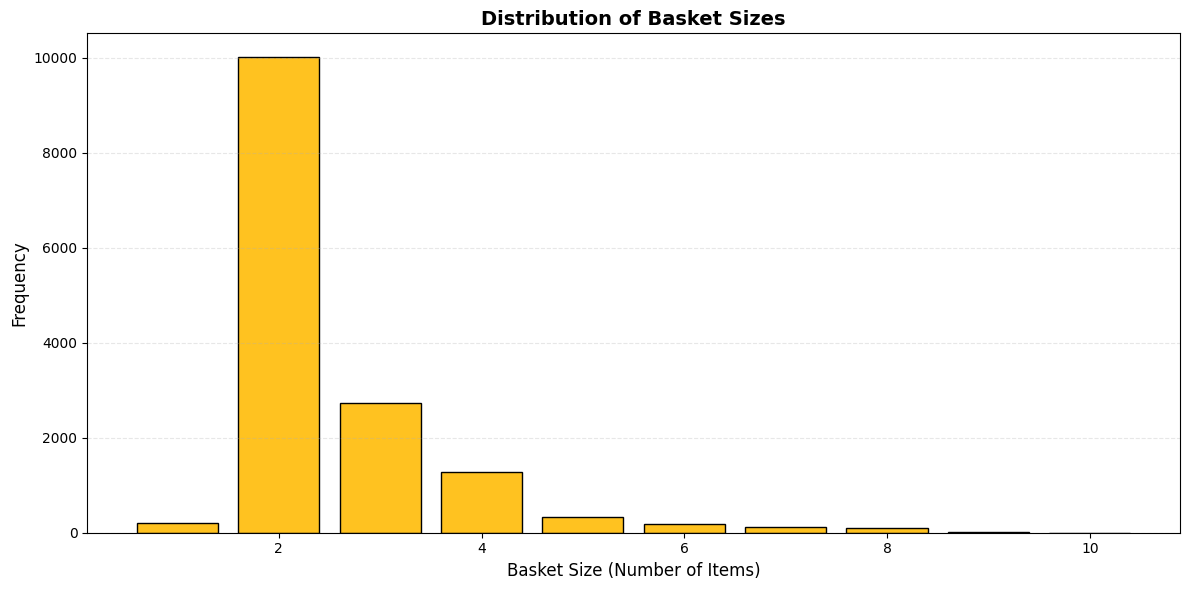

In [ ]:
# Display statistics
print(f"\nBasket Statistics:")
print(f"  Total baskets: {len(basket_df):,}")
print(f"  Average basket size: {basket_df['basket_size'].mean():.2f} items")
print(f"  Median basket size: {basket_df['basket_size'].median():.0f} items")
print(f"  Max basket size: {basket_df['basket_size'].max()} items")
print(f"  Single-item baskets: {(basket_df['basket_size'] == 1).sum():,} ({(basket_df['basket_size'] == 1).sum()/len(basket_df)*100:.1f}%))")
print(f"  Multi-item baskets: {(basket_df['basket_size'] > 1).sum():,} ({(basket_df['basket_size'] > 1).sum()/len(basket_df)*100:.1f}%)")

# Visualize basket size distribution
plt.figure(figsize=(12, 6))
basket_size_dist = basket_df['basket_size'].value_counts().sort_index().head(20)
plt.bar(basket_size_dist.index, basket_size_dist.values, color='#ffc220', edgecolor='black')
plt.xlabel('Basket Size (Number of Items)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Basket Sizes', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.show()

## Statistical Validation

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Select some top rules from FP-growth results to perform statistical validation

if 'rules_fp_sorted' in locals():
    # Select top rules (e.g., top 5)
    top_rules_to_validate = rules_fp_sorted.head(5) # You can adjust the number of rules here

    print("\nPerforming Statistical Validation on Top FP-Growth Rules:")

    for index, row in top_rules_to_validate.iterrows():
        antecedent = list(row['antecedents'])
        consequent = list(row['consequents'])

        # # For simplicity in the Chi-Squared test, we'll focus on pairs of items
        # if len(antecedent) == 1 and len(consequent) == 1:
        item1 = antecedent # Keep as list for multi-item case
        item2 = consequent # Keep as list for multi-item case

        print(f"\nStatistical Validation for Rule: {{{', '.join(item1)}}} -> {{{', '.join(item2)}}}")

        # Create boolean columns for the presence of antecedent and consequent sets in each basket

        if 'basket_df' in locals():
            basket_df['antecedent_present'] = basket_df['Item_description'].apply(lambda x: all(item in x for item in item1))
            basket_df['consequent_present'] = basket_df['Item_description'].apply(lambda x: all(item in x for item in item2))

            contingency_table = pd.crosstab(
                basket_df['antecedent_present'],
                basket_df['consequent_present']
            )

            print(f"Contingency Table for '{', '.join(item1)}' and '{', '.join(item2)}':")
            display(contingency_table)

            # Perform Chi-Squared test
            # This test is assessing the independence of the *presence* of the antecedent set
            # and the *presence* of the consequent set in a basket.
            chi2, p, dof, ex = chi2_contingency(contingency_table)

            print(f"Chi-Squared Test Results:")
            print(f"  Chi-Squared Statistic: {chi2:.2f}")
            print(f"  P-value: {p:.4f}")
            print(f"  Degrees of Freedom: {dof}")
            # print(f"  Expected Frequencies:\n{ex}") # Uncomment to see expected frequencies


            # Interpret the results
            alpha = 0.05
            print(f"\nInterpretation:")
            if p < alpha:
                print(f"  The p-value ({p:.4f}) is less than the significance level ({alpha}), so we reject the null hypothesis.")
                print(f"  There is a statistically significant association between the presence of '{', '.join(item1)}' and the presence of '{', '.join(item2)}' in a basket.")
            else:
                print(f"  The p-value ({p:.4f}) is greater than the significance level ({alpha}), so we fail to reject the null hypothesis.")
                print(f"  There is no statistically significant association between the presence of '{', '.join(item1)}' and the presence of '{', '.join(item2)}' in a basket based on this test.")

            print("-" * 50)
        else:
             print("The 'basket_df' DataFrame is not available. Cannot perform statistical validation for multi-item rules.")
             print("-" * 50)


else:
    print("The 'rules_fp_sorted' DataFrame is not available. Please run the FP-growth and rule generation steps first.")


Performing Statistical Validation on Top FP-Growth Rules:

Statistical Validation for Rule: {Bottled Beer} -> {Whole Milk}
Contingency Table for 'Bottled Beer' and 'Whole Milk':


consequent_present,False,True
antecedent_present,,
False,12029,2256
True,571,107


Chi-Squared Test Results:
  Chi-Squared Statistic: 0.00
  P-value: 1.0000
  Degrees of Freedom: 1

Interpretation:
  The p-value (1.0000) is greater than the significance level (0.05), so we fail to reject the null hypothesis.
  There is no statistically significant association between the presence of 'Bottled Beer' and the presence of 'Whole Milk' in a basket based on this test.
--------------------------------------------------

Statistical Validation for Rule: {Sausage} -> {Whole Milk}
Contingency Table for 'Sausage' and 'Whole Milk':


consequent_present,False,True
antecedent_present,,
False,11831,2229
True,769,134


Chi-Squared Test Results:
  Chi-Squared Statistic: 0.58
  P-value: 0.4455
  Degrees of Freedom: 1

Interpretation:
  The p-value (0.4455) is greater than the significance level (0.05), so we fail to reject the null hypothesis.
  There is no statistically significant association between the presence of 'Sausage' and the presence of 'Whole Milk' in a basket based on this test.
--------------------------------------------------

Statistical Validation for Rule: {Newspapers} -> {Whole Milk}
Contingency Table for 'Newspapers' and 'Whole Milk':


...

Chi-Squared Test Results:
  Chi-Squared Statistic: 0.74
  P-value: 0.3902
  Degrees of Freedom: 1

Interpretation:
  The p-value (0.3902) is greater than the significance level (0.05), so we fail to reject the null hypothesis.
  There is no statistically significant association between the presence of 'Newspapers' and the presence of 'Whole Milk' in a basket based on this test.
--------------------------------------------------

Statistical Validation for Rule: {Domestic Eggs} -> {Whole Milk}
Contingency Table for 'Domestic Eggs' and 'Whole Milk':


consequent_present,False,True
antecedent_present,,
False,12124,2284
True,476,79


Chi-Squared Test Results:
  Chi-Squared Statistic: 0.93
  P-value: 0.3338
  Degrees of Freedom: 1

Interpretation:
  The p-value (0.3338) is greater than the significance level (0.05), so we fail to reject the null hypothesis.
  There is no statistically significant association between the presence of 'Domestic Eggs' and the presence of 'Whole Milk' in a basket based on this test.
--------------------------------------------------

Statistical Validation for Rule: {Frankfurter} -> {Whole Milk}
Contingency Table for 'Frankfurter' and 'Whole Milk':


consequent_present,False,True
antecedent_present,,
False,12114,2284
True,486,79


Chi-Squared Test Results:
  Chi-Squared Statistic: 1.31
  P-value: 0.2527
  Degrees of Freedom: 1

Interpretation:
  The p-value (0.2527) is greater than the significance level (0.05), so we fail to reject the null hypothesis.
  There is no statistically significant association between the presence of 'Frankfurter' and the presence of 'Whole Milk' in a basket based on this test.
--------------------------------------------------


## Impact Analysis

In [ ]:
# Calculate key metrics
avg_basket_size = basket_df['basket_size'].mean()
total_baskets = len(basket_df)
months_of_data = 24  # 2 years
monthly_baskets = total_baskets / months_of_data

print(f"\nCurrent State Metrics:")
print(f"  Average basket size: {avg_basket_size:.2f} items")
print(f"  Total baskets analyzed: {total_baskets:,}")
print(f"  Monthly baskets: {monthly_baskets:.0f}")

# Calculate potential impact from top rules
top_5_rules = resultsinDataFrame.nlargest(5, columns="Confidence") # Use nlargest to get top 5 by Confidence
avg_lift = top_5_rules['Lift'].mean()
avg_confidence = top_5_rules['Confidence'].mean()

print(f"\nTop 5 Rules Performance:")
print(f"  Average lift: {avg_lift:.2f}x")
print(f"  Average confidence: {avg_confidence:.1%}")

# Estimate impact (conservative assumptions)
adoption_rate = 0.10  # 10% of customers adopt bundling
# Assuming the lift represents the potential increase in items per basket for those who adopt
# This is a simplification; a more complex model could estimate revenue impact based on item prices
basket_increase_pct = (avg_lift - 1) * adoption_rate

new_basket_size = avg_basket_size * (1 + basket_increase_pct)
additional_items_per_basket = new_basket_size - avg_basket_size


print("PROJECTED IMPACT (Conservative Estimate)")


print(f"\nAssumptions:")
print(f"  • Bundle adoption rate: {adoption_rate:.0%}")
print(f"  • Average lift from top 5 rules: {avg_lift:.2f}x")

print(f"\nBasket Size Impact:")
print(f"  Current avg basket: {avg_basket_size:.2f} items")
print(f"  Projected avg basket: {new_basket_size:.2f} items")
print(f"  Increase: +{additional_items_per_basket:.2f} items (+{basket_increase_pct*100:.1f}%)")

print(f"\nVolume Impact:")
monthly_additional_items = monthly_baskets * additional_items_per_basket
annual_additional_items = monthly_additional_items * 12

print(f"  Additional items per month: {monthly_additional_items:.0f}")
print(f"  Additional items per year: {annual_additional_items:.0f}")

# Revenue impact (assuming $5 per item)
avg_item_price = 5.00
monthly_revenue_increase = monthly_additional_items * avg_item_price
annual_revenue_increase = monthly_revenue_increase * 12

print(f"\nRevenue Impact (assuming ${avg_item_price:.2f} avg item price):")
print(f"  Monthly revenue increase: ${monthly_revenue_increase:,.0f}")
print(f"  Annual revenue increase: ${annual_revenue_increase:,.0f}")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Basket Size Comparison
basket_size_data = pd.DataFrame({
    'Metric': ['Current Avg', 'Projected Avg'],
    'Basket Size': [avg_basket_size, new_basket_size]
})
colors_basket = ['#ffc220', '#b88500']
axes[0].bar(basket_size_data['Metric'], basket_size_data['Basket Size'], color=colors_basket)
axes[0].set_title('Average Basket Size')
axes[0].set_ylabel('Number of Items')
axes[0].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
#axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].tick_params(left=False, bottom=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f')


# Chart 2: Monthly Revenue Impact
revenue_data = pd.DataFrame({
    'Metric': ['Current\nRevenue', 'Additional\nRevenue', 'Total\nProjected'],
    'Amount': [
        monthly_baskets * avg_basket_size * avg_item_price,
        monthly_revenue_increase,
        (monthly_baskets * avg_basket_size * avg_item_price) + monthly_revenue_increase
    ]
})
colors_rev = ['#ffc220', '#4CAF50', '#2196F3']
axes[1].bar(revenue_data['Metric'], revenue_data['Amount'], color=colors_rev)
axes[1].set_title('Monthly Revenue Impact')
axes[1].set_ylabel('Revenue ($)')
axes[1].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
#axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].tick_params(left=False, bottom=False)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='${:,.0f}')


# Chart 3: Annual Revenue Impact
annual_revenue_data = pd.DataFrame({
    'Metric': ['Current\nAnnual\nRevenue', 'Additional\nAnnual\nRevenue', 'Total\nProjected\nAnnual'],
    'Amount': [
        (monthly_baskets * avg_basket_size * avg_item_price) * 12,
        annual_revenue_increase,
        ((monthly_baskets * avg_basket_size * avg_item_price) + monthly_revenue_increase) * 12
    ]
})
colors_annual = ['#ffc220', '#4CAF50', '#2196F3']
axes[2].bar(annual_revenue_data['Metric'], annual_revenue_data['Amount'], color=colors_annual)
axes[2].set_title('Annual Revenue Impact')
axes[2].set_ylabel('Revenue ($)')
axes[2].spines[['top', 'right', 'left', 'bottom']].set_visible(False)
#axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].tick_params(left=False, bottom=False)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='${:,.0f}')


plt.tight_layout()
plt.show()